 # Étape 1 – Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("../data/row/Airbnb_Open_Data.csv")

 ## 1. Decouverte du dataset

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


 ## 2. Description du le dataset

In [4]:
rows, cols = df.shape
pd.options.display.float_format = '{:.3f}'.format
print(f"Number of observations (rows): {rows}")
print(f"Number of variables (columns): {cols}")
print("\nVariable Types and Info:")
df.info()


Number of observations (rows): 102599
Number of variables (columns): 26

Variable Types and Info:
<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str 

on a un probleme au niveau de(price,service_fees) de type object alors qu'ils doient etre sous forme de type float le probleme ce caracterise sur le symbole de "$" 

 - la on vas fixe ce problem de (price et service_fees)avec cette fonction pour qu'on puisse calculer ces statisque descriptives ulterierement

In [5]:
cols=["price","service fee"]
df[cols]=(
    df[cols]
    .replace({"\\$": "", ",": ""}, regex=True)
    .astype(float)
)

In [6]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

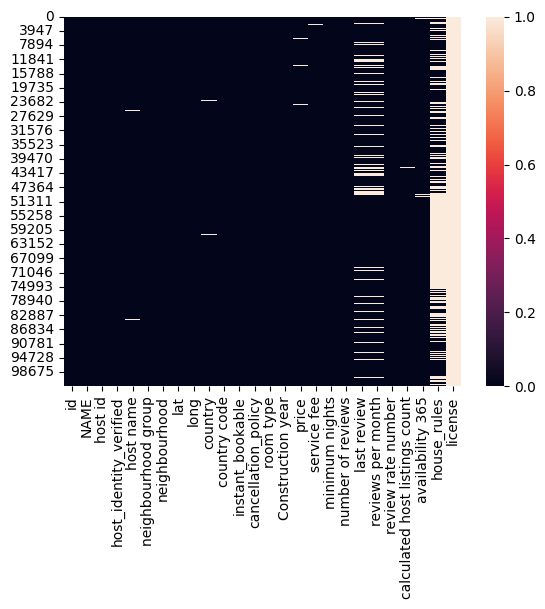

In [7]:
# la proportion des valeur manquant 
sns.heatmap(df.isna())
plt.show()

la on voit que la colonne license contient qu 3 valeur non null(102592 out of 102600 )alors qu'on a pas besoin de cette colonne et house_rules y a(50469 non-null  et 52131 null )ce qui nous dis que celle ci est Très problématique, pour last review et reviews per month (15% de valeurs manquante) pour l'instant sera acceptable

In [8]:
(df.isnull().sum() / len(df)) * 100

id                                0.000
NAME                              0.244
host id                           0.000
host_identity_verified            0.282
host name                         0.396
neighbourhood group               0.028
neighbourhood                     0.016
lat                               0.008
long                              0.008
country                           0.519
country code                      0.128
instant_bookable                  0.102
cancellation_policy               0.074
room type                         0.000
Construction year                 0.209
price                             0.241
service fee                       0.266
minimum nights                    0.399
number of reviews                 0.178
last review                      15.490
reviews per month                15.477
review rate number                0.318
calculated host listings count    0.311
availability 365                  0.437
house_rules                      50.810


 ###  Analyse des variables


In [9]:
df.describe().round(2)

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,102599.000,102599.000,102591.000,102591.000,102385.000,102352.000,102326.000,102190.000,102416.000,86720.000,102273.000,102280.000,102151.000
mean,29146234.520,49254111474.330,40.730,-73.950,2012.490,625.290,125.030,8.140,27.480,1.370,3.280,7.940,141.130
std,16257505.610,28538996644.370,0.060,0.050,5.770,331.670,66.330,30.550,49.510,1.750,1.280,32.220,135.440
min,1001254.000,123600518.000,40.500,-74.250,2003.000,50.000,10.000,-1223.000,0.000,0.010,1.000,1.000,-10.000
25%,15085814.500,24583328475.000,40.690,-73.980,2007.000,340.000,68.000,2.000,1.000,0.220,2.000,1.000,3.000
50%,29136603.000,49117739352.000,40.720,-73.950,2012.000,624.000,125.000,3.000,7.000,0.740,3.000,1.000,96.000
75%,43201198.000,73996495817.000,40.760,-73.930,2017.000,913.000,183.000,5.000,30.000,2.000,4.000,2.000,269.000
max,57367417.000,98763129024.000,40.920,-73.710,2022.000,1200.000,240.000,5645.000,1024.000,90.000,5.000,332.000,3677.000


d'apres ces resultats on voies qu'il ya des resultats anormales comme min night (-1223) et un max de(5645)ou aussi availabilty par ans d'un max de
(3677) ou d'un min de (-10)

In [10]:
#la on va supp les min nights<0   et     0 < availability par an < 365
df = df[df["minimum nights"] >= 0]

df = df[
    (df["availability 365"] >= 0) &
    (df["availability 365"] <= 365)
]


In [11]:
#puis la on a pas besoin des statistique desciprive des valeur comme id et host id on vas filtrer les cols qui nous interessent
#comme ilimuner id et id host
cols_interessantes = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365",
    "lat",
    "long",
    "Construction year"
]

df[cols_interessantes].describe().round(2)


,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,lat,long,Construction year
count,98325.000,98298.000,98560.000,98434.000,83590.000,98275.000,98270.000,98560.000,98552.000,98552.000,98394.000
mean,625.810,125.130,8.160,27.150,1.390,3.290,8.060,134.480,40.730,-73.950,2012.490
std,331.730,66.340,28.600,48.850,1.750,1.280,32.630,129.810,0.060,0.050,5.760
min,50.000,10.000,1.000,0.000,0.010,1.000,1.000,0.000,40.500,-74.250,2003.000
25%,340.000,68.000,2.000,1.000,0.230,2.000,1.000,2.000,40.690,-73.980,2008.000
50%,626.000,125.000,3.000,7.000,0.760,3.000,1.000,90.000,40.720,-73.950,2012.000
75%,913.000,183.000,5.000,30.000,2.030,4.000,2.000,254.000,40.760,-73.930,2017.000
max,1200.000,240.000,5645.000,1024.000,90.000,5.000,332.000,365.000,40.920,-73.710,2022.000


In [12]:
initial_rows = df.shape[0]
current_rows = df.shape[0]
removed_rows = initial_rows - current_rows
percentage_removed = (removed_rows / initial_rows) * 100
print("Nombre d'observations après nettoyage :", current_rows)
print("Pourcentage supprime :" ,  '{:.2f}%'.format(percentage_removed))

Nombre d'observations après nettoyage : 98560
Pourcentage supprime : 0.00%


 - La variable host id est un identifiant unique des propriétaires et ne possède pas de signification numérique directe

In [13]:
ignored_columns=['id','NAME','host id','license','textes longs (house_rules)']

  ## Variables catégorielles importantes

 #### 1. Construction year

In [14]:
df['Construction year'].describe()

count   98394.000
mean     2012.490
std         5.764
min      2003.000
25%      2008.000
50%      2012.000
75%      2017.000
max      2022.000
Name: Construction year, dtype: float64

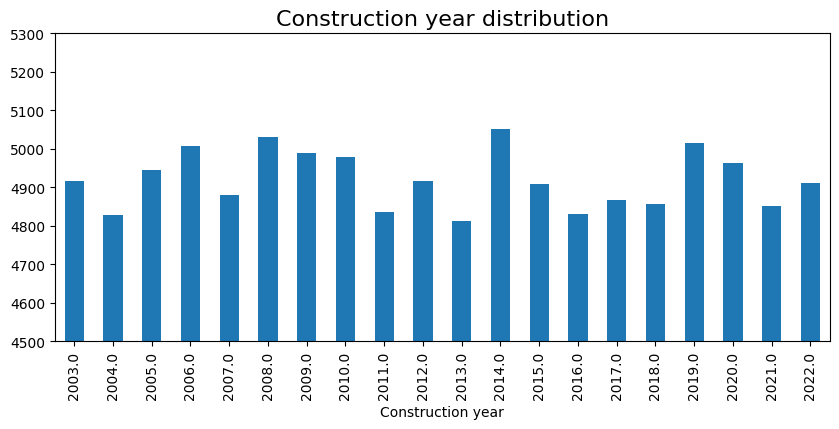

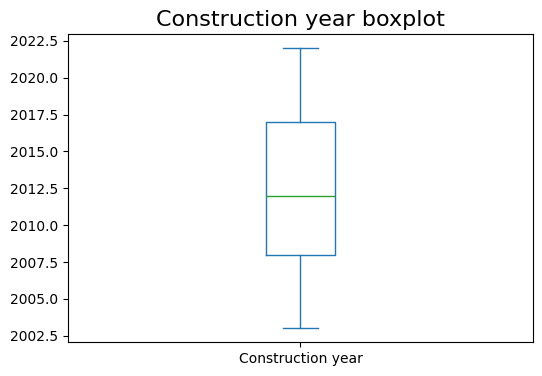

In [15]:
plt.figure(figsize=(10,4))
df['Construction year'].value_counts().sort_index().plot(kind='bar')
plt.title('Construction year distribution', fontsize=16)
plt.ylim(4500,5300)
plt.show()
plt.figure(figsize=(6,4))
df['Construction year'].plot(kind='box')
plt.title('Construction year boxplot', fontsize=16)
plt.show()

- La variable **construction year** présente une distribution relativement homogène entre 2003 et 2022. La médiane se situe autour de 2012, et 50 % des logements ont été construits entre 2007 et 2017. Le boxplot ne révèle pas de valeurs aberrantes significatives, ce qui indique une répartition stable des années de construction 

 #### 2- neighbourhood group

In [16]:
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        41869
Brooklyn         40192
Queens           12901
Bronx             2650
Staten Island      930
brookln              1
manhatan             1
Name: count, dtype: int64

 les valeur bookln et manhatan sont des fote d'aurtographe

In [17]:
df['neighbourhood group']=df['neighbourhood group'].replace({'brookln':'Brooklyn','manhatan':'Manhattan'})
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        41870
Brooklyn         40193
Queens           12901
Bronx             2650
Staten Island      930
Name: count, dtype: int64

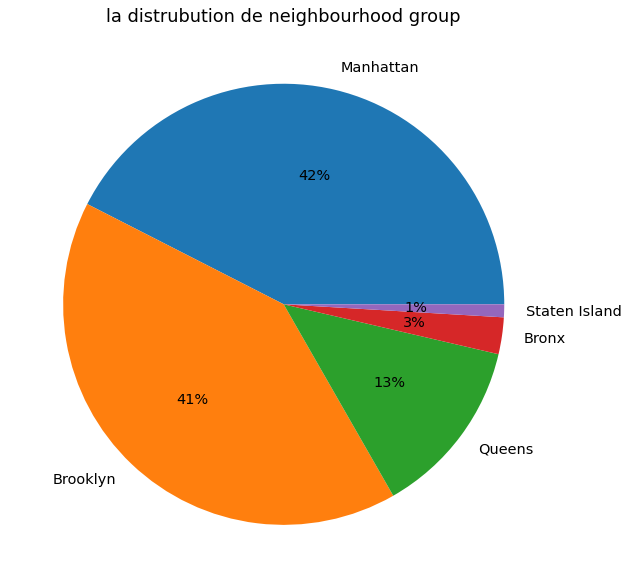

In [18]:
plt.figure(figsize=(8,8), dpi=80)
df['neighbourhood group'].value_counts().plot(kind='pie', autopct='%1.0f%%', startangle=360, fontsize=13)
plt.title('la distrubution de neighbourhood group', fontsize=16)
plt.tight_layout()

- **Manhattan** est la plus frequence Airbnb dans le je de donne avec *43%* , et **staten Island** et le moin frequent avec un pourcentage *1%* de donne .

 #### 3- instant_bokable

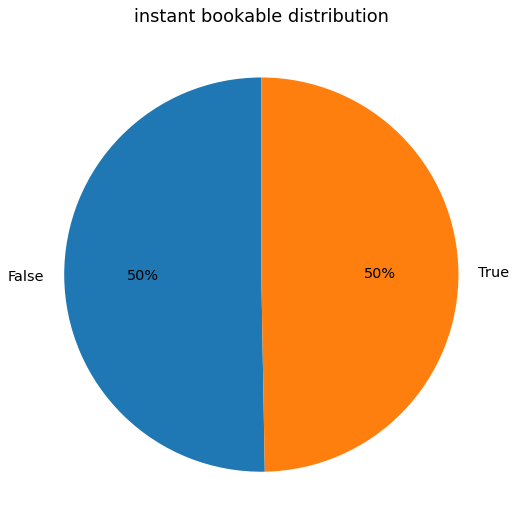

In [19]:
plt.figure(figsize=(8,8),dpi=80)
df['instant_bookable'].value_counts().plot(kind='pie',autopct='%1.0f%%', startangle=90, fontsize=13)
plt.title('instant bookable distribution', fontsize=16)
plt.show()

 
- la variable **instanat_boookable** montre un destribution normale des données

 #### 4. cancellation_policy

In [20]:
df['cancellation_policy'].value_counts()

cancellation_policy
moderate    32954
strict      32787
flexible    32763
Name: count, dtype: int64

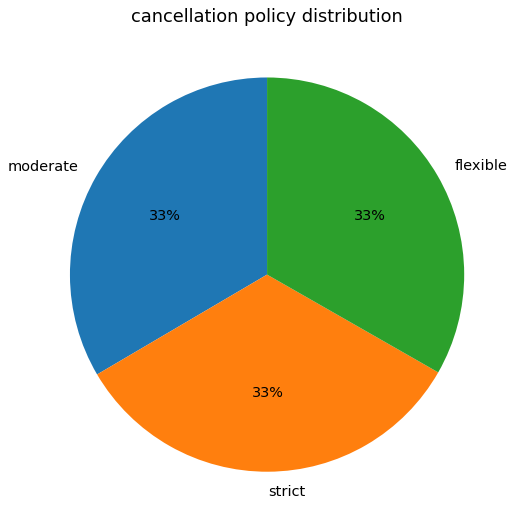

In [21]:
plt.figure(figsize=(8,8), dpi=80)
df['cancellation_policy'].value_counts().plot(kind='pie',autopct='%1.0f%%', startangle=90, fontsize=13)
plt.title('cancellation policy distribution', fontsize=16)
plt.show()

- La variable **cancellation policy** montre une répartition presque parfaitement équilibrée entre les trois types de politiques, avec environ *33%* pour chaqu'un des trois valeurs 

 #### 5. room type

In [22]:
df['room type'].value_counts()

room type
Entire home/apt    51485
Private room       44804
Shared room         2157
Hotel room           114
Name: count, dtype: int64

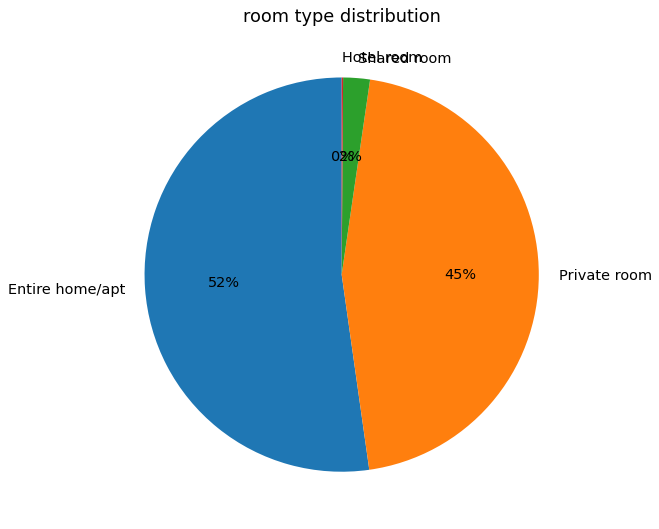

In [23]:
plt.figure(figsize=(8,8), dpi=80)
df['room type'].value_counts().plot(kind='pie', autopct='%1.0f%%', startangle=90, fontsize=13)
plt.title('room type distribution', fontsize=16)
plt.show()    


- La variable **room type** montre que les logements entiers représentent la plus grande proportion *52%*, suivis des chambres privées *45%* , tandis que les chambres partagées et les hôtels constituent une part très faible du total

 ## Variables numériques importantes
✔ availability 365
✔ calculated host listings count
✔ Construction year

  #### 1. Variables catégorielles importantes

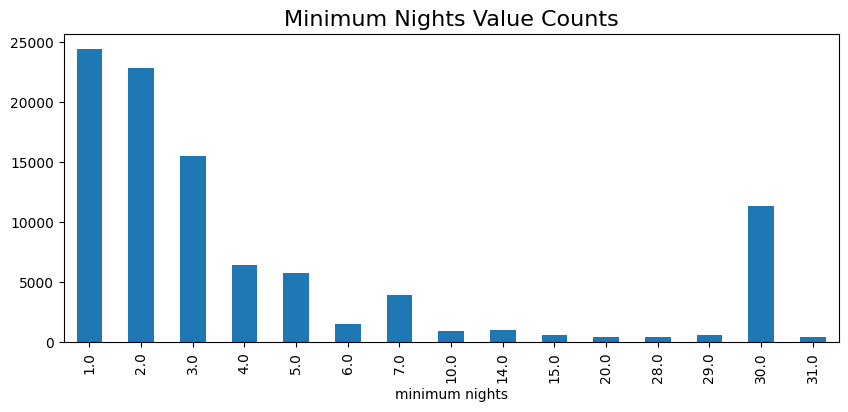

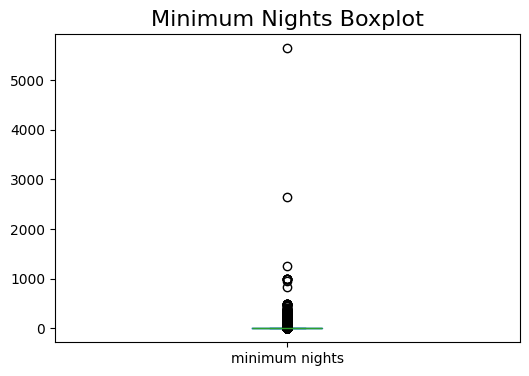

In [24]:
plt.figure(figsize=(10,4))
df['minimum nights'].value_counts()\
    .sort_index()\
    .where(lambda x: x > 400)\
    .dropna()\
    .plot(kind='bar')
plt.title('Minimum Nights Value Counts', fontsize=16)
plt.show()
plt.figure(figsize=(6,4))
df['minimum nights'].plot(kind='box')
plt.title('Minimum Nights Boxplot', fontsize=16)  
plt.show()

 - La variable minimum nights montre que la majorité des annonces exigent un séjour minimum très court, principalement 1 ou 2 nuits, qui sont les valeurs les plus fréquentes. Les séjours de 3 à 5 nuits restent également courants, tandis que les durées plus longues deviennent progressivement rares. On observe aussi une présence notable de 30 nuits, correspondant probablement à des locations mensuelles. Le boxplot révèle cependant la présence de valeurs aberrantes très élevées, indiquant quelques annonces avec des exigences de séjour exceptionnellement longues

#### 2. number of reviews

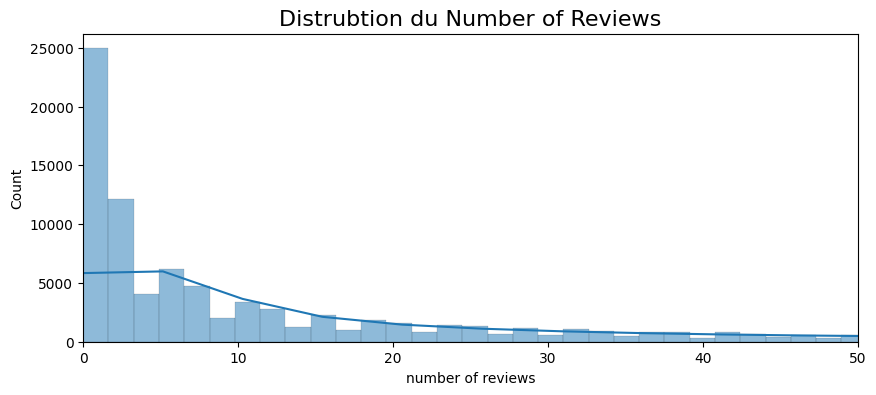

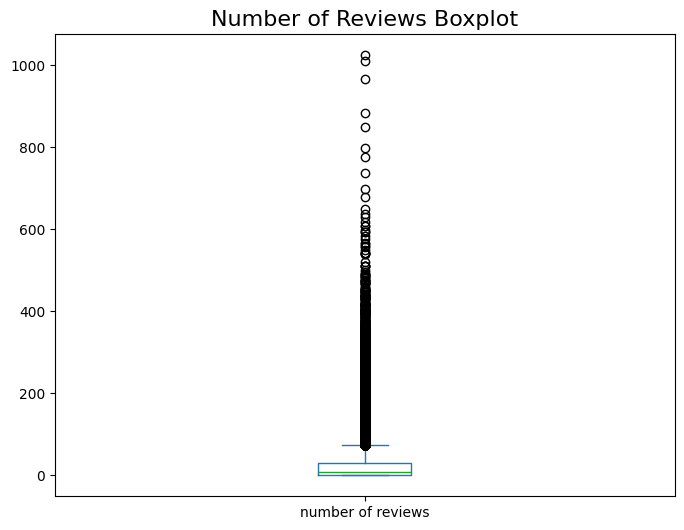

In [25]:
plt.figure(figsize=(10,4))
sns.histplot(df['number of reviews'],kde=True)
plt.xlim(0,50)
plt.title('Distrubtion du Number of Reviews', fontsize=16)
plt.show()
plt.figure(figsize=(8,6))
df['number of reviews'].plot(kind='box')
plt.title('Number of Reviews Boxplot', fontsize=16)
plt.show()

 - La variable number of reviews montre que la majorité des annonces ont un faible nombre d’avis, avec une forte concentration autour de 0 à 5 avis. La médiane est de 7 avis, ce qui signifie que la moitié des logements ont moins de 7 avis. La distribution est très asymétrique à droite, avec quelques annonces ayant un nombre très élevé d’avis (jusqu’à 1024), indiquant la présence de logements très populaires mais rares

 #### 3- reviews per month

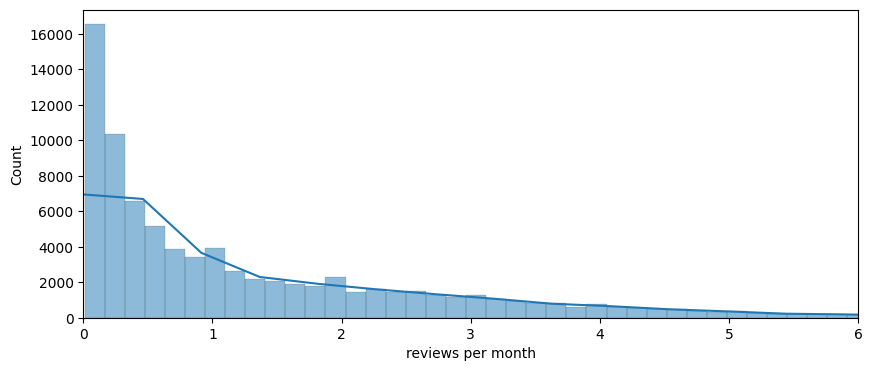

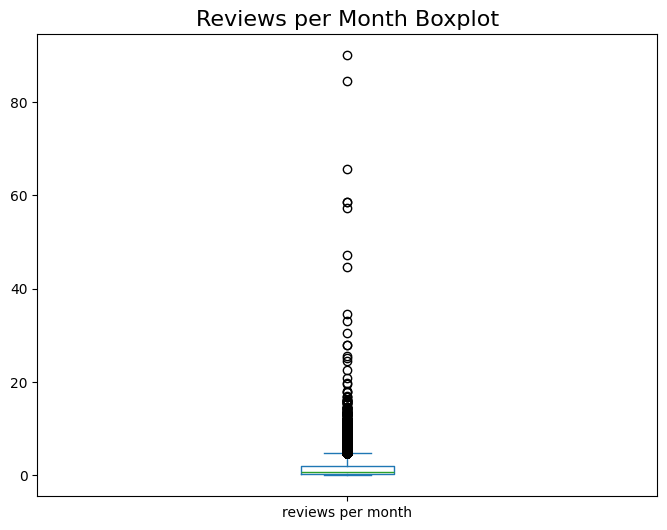

In [26]:
plt.figure(figsize=(10,4))
sns.histplot(df['reviews per month'],kde=True)
plt.xlim(0,6)
plt.show()
plt.figure(figsize=(8,6))
df['reviews per month'].plot(kind='box')
plt.title('Reviews per Month Boxplot', fontsize=16)
plt.show()


La variable **reviews per month** indique que la majorité des annonces reçoivent moins de 2 avis par mois, avec une médiane d’environ 0,74, ce qui reflète une activité généralement faible. L’histogramme montre une distribution fortement asymétrique à droite, avec une forte concentration de valeurs proches de zéro. Le boxplot met en évidence la présence de nombreuses valeurs aberrantes élevées, correspondant à quelques annonces exceptionnellement actives recevant un nombre très important d’avis mensuels (jusqu’à 90)

 #### 4. calculated host listings count

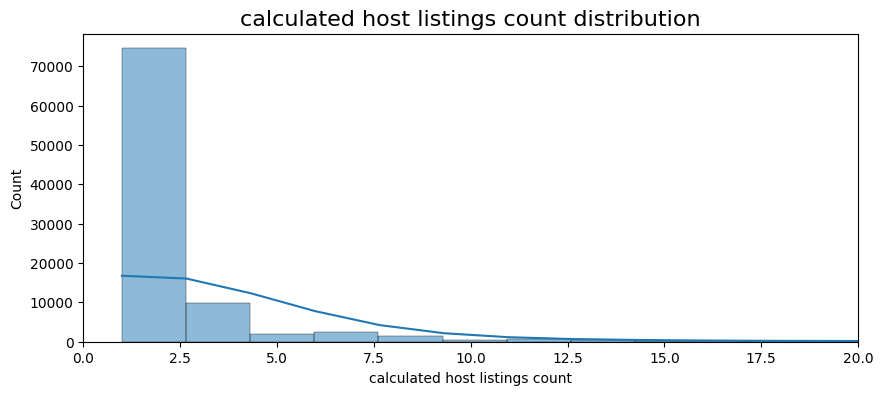

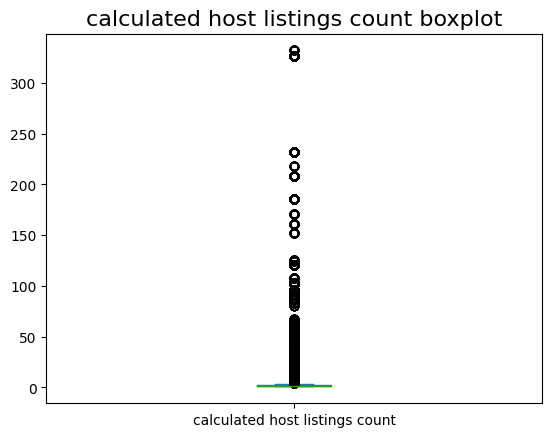

In [27]:
plt.figure(figsize=(10,4))
sns.histplot(df['calculated host listings count'], bins=200, kde=True)
plt.title('calculated host listings count distribution', fontsize=16)
plt.xlim(0,20)
plt.show()
df['calculated host listings count'].plot(kind='box')
plt.title('calculated host listings count boxplot', fontsize=16)    
plt.show()  

 ### 5. availability 365

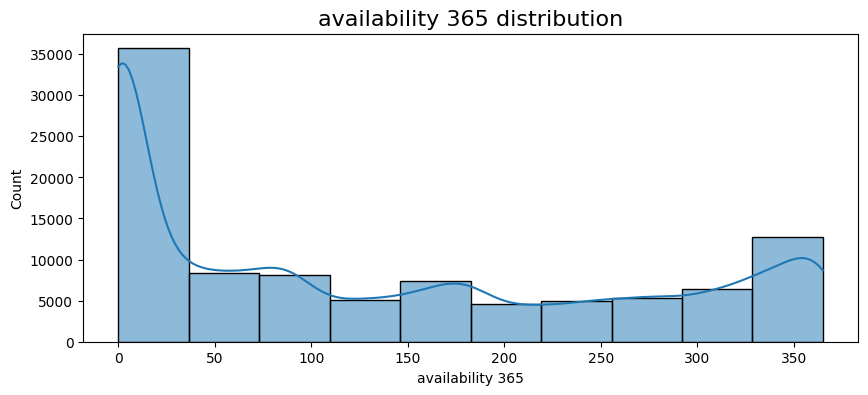

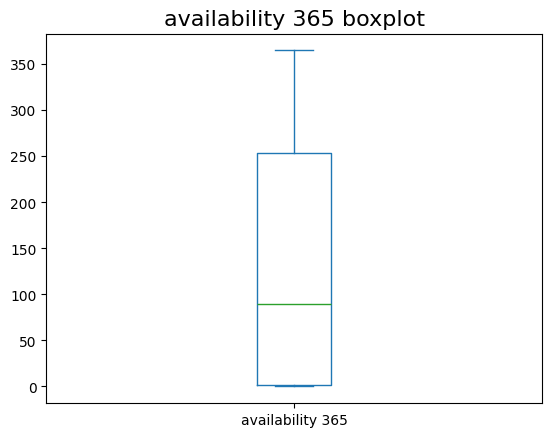

In [28]:
plt.figure(figsize=(10,4))
sns.histplot(df['availability 365'],bins=10, kde=True)   
plt.title('availability 365 distribution', fontsize=16)
plt.show()
df['availability 365'].plot(kind='box')
plt.title('availability 365 boxplot', fontsize=16)
plt.show()

 - La variable availability 365 présente une forte variabilité dans le nombre de jours disponibles par an. La médiane se situe autour de 98 jours, ce qui signifie que la moitié des logements sont disponibles moins de 98 jours par an. L’intervalle interquartile (environ 4 à 270 jours) indique une dispersion importante des disponibilités. L’histogramme suggère une distribution bimodale, avec une concentration de logements soit très peu disponibles (proches de 0 jour), soit disponibles presque toute l’année (proches de 365 jours).

#### 6. review rate number

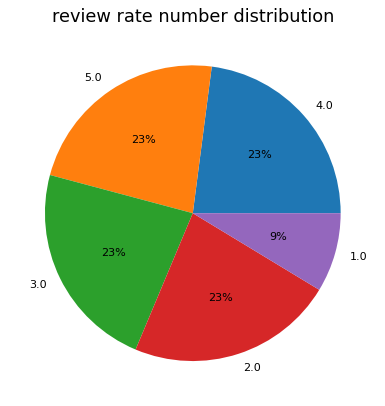

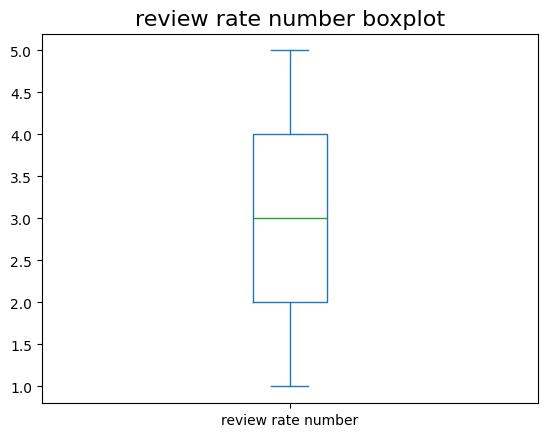

In [29]:
plt.figure(figsize=(6,6),dpi=80)
df['review rate number'].value_counts().plot(kind='pie',autopct='%1.0f%%')
plt.title('review rate number distribution', fontsize=16)
plt.show()
df['review rate number'].plot(kind='box')
plt.title('review rate number boxplot', fontsize=16)
plt.show()

  - La variable review rate number présente une répartition relativement équilibrée entre les notes 2, 3, 4 et 5, chacune représentant environ 23 % des évaluations, tandis que la note 1 est nettement moins fréquente (environ 9 %). La médiane se situe autour de 3, ce qui indique une tendance générale vers des évaluations modérées à positives. Le boxplot ne révèle pas de valeurs aberrantes, ce qui est attendu pour une variable discrète limitée entre 1 et 5. Globalement, la distribution suggère que la majorité des avis sont favorables.

 ## Variable cible


### Price

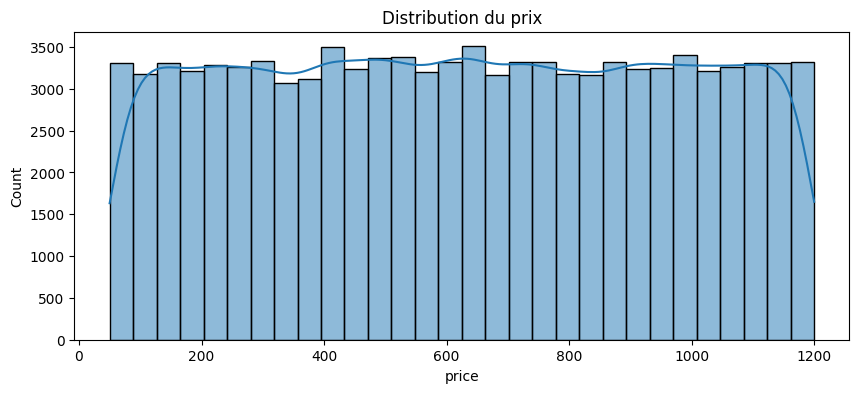

In [30]:
plt.figure(figsize=(10,4))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution du prix")
plt.show()

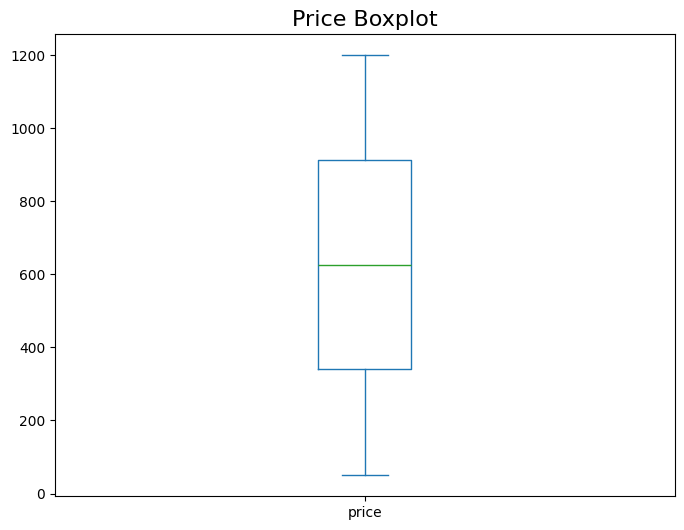

In [31]:
plt.figure(figsize=(8,6))
df['price'].plot(kind='box')
plt.title('Price Boxplot', fontsize=16) 
plt.show()

- La variable price présente une moyenne d’environ 625, très proche de la médiane 624, ce qui suggère une distribution relativement équilibrée. Les prix s’étendent de 50 à 1200, avec 50% des valeurs comprises entre 340 et 913. L’histogramme montre une dispersion importante des prix sur toute la plage, tandis que le boxplot ne révèle pas de valeurs aberrantes extrêmes.

 ### Price & Room Type

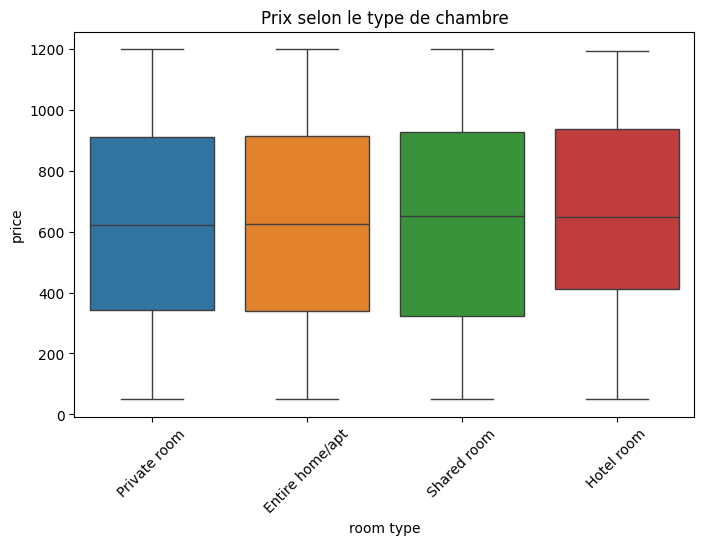

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["room type"], y=df["price"],hue=df['room type'])
plt.title("Prix selon le type de chambre")
plt.xticks(rotation=45)
plt.show()

- Les logements de type Entire home/apt présentent en moyenne des prix plus élevés que les chambres privées ou partagées.

  ### Price & Neighbourhood Group

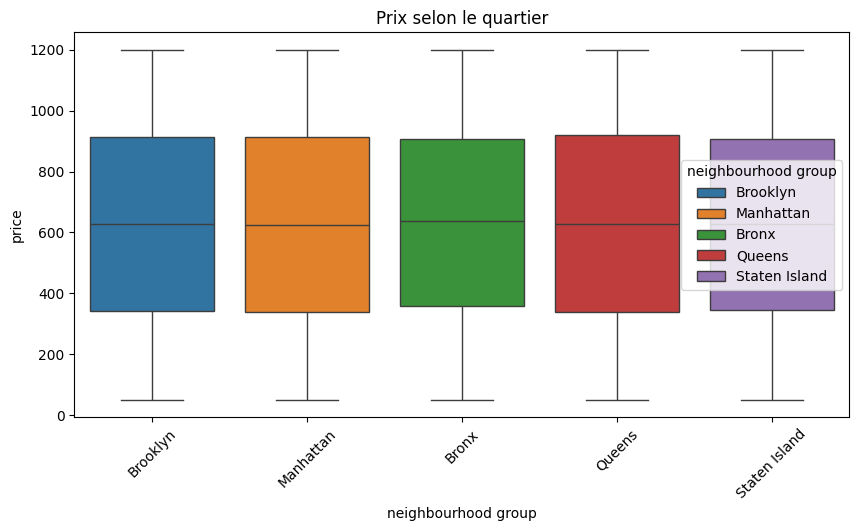

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["neighbourhood group"], y=df["price"],hue=df["neighbourhood group"])
plt.title("Prix selon le quartier")
plt.xticks(rotation=45)
plt.show()

- Le prix varie significativement selon le quartier, ce qui montre l’impact de la localisation sur la tarification.

 ### Price vs Minimum Nights

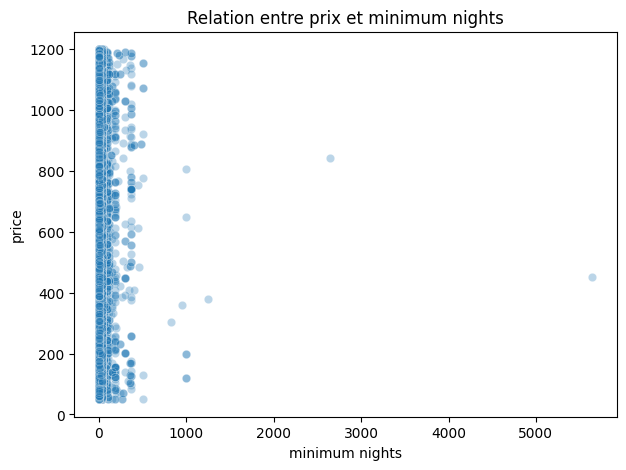

In [34]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["minimum nights"], y=df["price"], alpha=0.3)
plt.title("Relation entre prix et minimum nights")
plt.show()


  - Aucune relation linéaire forte n’est observée entre le nombre minimum de nuits et le prix.

 ### Price vs Number of Reviews

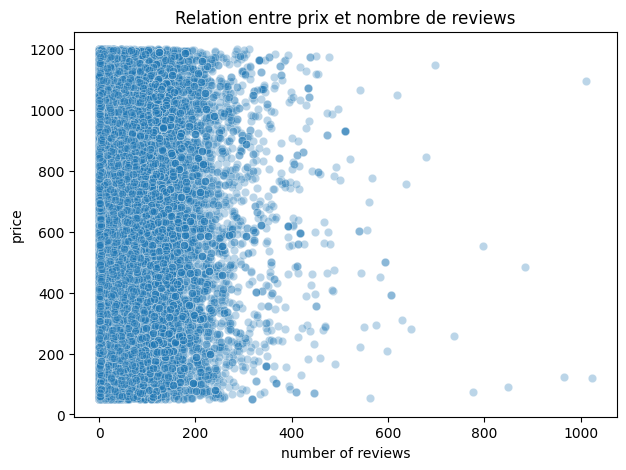

In [35]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["number of reviews"], y=df["price"], alpha=0.3)
plt.title("Relation entre prix et nombre de reviews")
plt.show()

 - Le nombre de reviews ne semble pas influencer directement le prix, confirmant la faible corrélation observée précédemment.

Variable cible (dépendante)
price(Justification ):
L’objectif du projet est d’analyser et de prédire le prix d’un logement Airbnb.
Le prix est une variable quantitative continue.
Nous cherchons à comprendre quels facteurs influencent ce prix.
Le problème est donc un problème de régression.

Variables explicatives (indépendantes):
Ce sont toutes les variables susceptibles d’influencer le prix.
Variables numériques :minimum nights, number of reviews, reviews per month, review rate number, calculated host listings count, availability 365, lat,
long, Construction year
La variable cible retenue est "price", car l’objectif du projet est de prédire le prix d’un logement Airbnb en fonction de ses caractéristiques.
Les variables décrivant la localisation, les caractéristiques du logement et son activité sont considérées comme variables explicatives.
Les variables d’identification (id, host id, etc.) ont été exclues car elles ne possèdent aucune valeur prédictive.

  #### Matrice de corr


In [36]:
variables_corr = [
    "price",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365",
    "lat",
    "long",
    "Construction year"
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[variables_corr])
corr_scaled = pd.DataFrame(X_scaled, columns=variables_corr).corr()
corr_scaled

,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,lat,long,Construction year
price,1.000,-0.005,0.006,0.004,-0.006,-0.001,-0.002,-0.006,0.002,-0.004
minimum nights,-0.005,1.000,-0.054,-0.096,-0.001,0.090,0.071,0.018,-0.042,0.002
number of reviews,0.006,-0.054,1.000,0.591,-0.019,-0.081,0.100,-0.026,0.071,0.003
reviews per month,0.004,-0.096,0.591,1.000,0.036,-0.026,0.098,-0.020,0.117,0.004
review rate number,-0.006,-0.001,-0.019,0.036,1.000,0.024,0.003,-0.003,0.014,0.005
calculated host listings count,-0.001,0.090,-0.081,-0.026,0.024,1.000,0.175,0.032,-0.106,-0.003
availability 365,-0.002,0.071,0.100,0.098,0.003,0.175,1.000,-0.009,0.072,-0.008
lat,-0.006,0.018,-0.026,-0.020,-0.003,0.032,-0.009,1.000,0.074,0.006
long,0.002,-0.042,0.071,0.117,0.014,-0.106,0.072,0.074,1.000,0.001
Construction year,-0.004,0.002,0.003,0.004,0.005,-0.003,-0.008,0.006,0.001,1.000


- Les variables numériques ont été standardisées (moyenne 0, écart-type 1) avant certaines analyses afin d’assurer une contribution équitable des variables

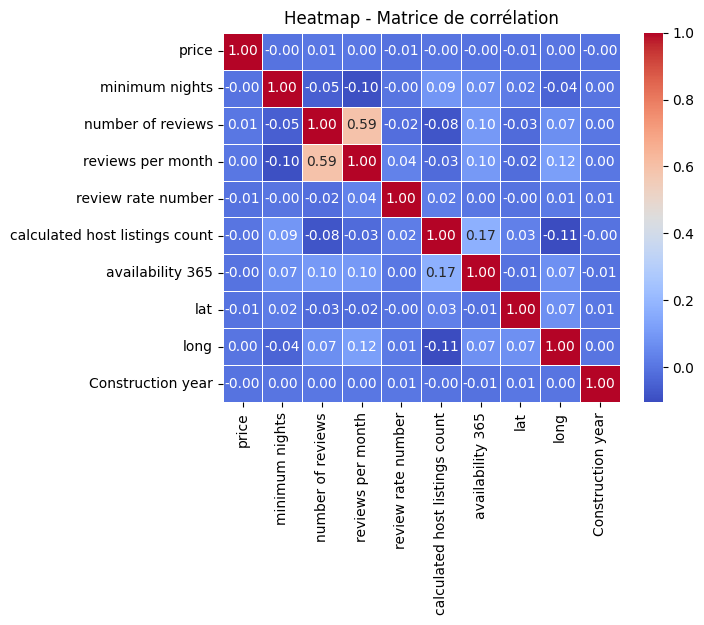

In [37]:
corr_matrix = df[variables_corr].corr()
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5 )
plt.title("Heatmap - Matrice de corrélation")
plt.show()

La matrice de corrélation met en évidence une absence de corrélation linéaire significative entre la variable cible "price" et les variables numériques étudiées.
En revanche, une corrélation positive modérée (0.59) est observée entre "number of reviews" et "reviews per month", ce qui est cohérent puisque ces deux variables sont liées.
Globalement, les corrélations restent faibles, suggérant que le prix pourrait être influencé par des variables catégorielles ou par des relations non linéaires.

 ## 2 – Preprocessing des données

- Vérifier l’existence des doublons

In [38]:
duplicates = df.duplicated().sum()
print("Nombre de doublons :", duplicates)

Nombre de doublons : 503


In [39]:
unique_ids = df["id"].nunique()
total_rows = df.shape[0]

print("Nombre d'ID uniques :", unique_ids)
print("Nombre total de lignes :", total_rows)

Nombre d'ID uniques : 98057
Nombre total de lignes : 98560


- on verifie si id est unique 

In [40]:
df["id"].duplicated().sum()


np.int64(503)

 - Il existe des doublons

In [41]:
df = df.drop_duplicates()

In [42]:
df["id"].duplicated().sum()

np.int64(0)

 - 503 doublons exacts ont été détectés et supprimés afin d’éviter une redondance d’information susceptible de biaiser l’analyse et la modélisation

In [43]:
df.duplicated().sum()

np.int64(0)

- id représente normalement un identifiant unique d’annonce donc ne doit pas etre dupliquer
- Une vérification des doublons a révélé la présence de 503 lignes entièrement identiques.
Ces doublons ont été supprimés à l’aide de la fonction drop_duplicates() afin d’éviter toute redondance d’information.
Après suppression, chaque identifiant d’annonce est unique et aucune duplication n’est observée.

In [44]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / df.shape[0]) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_df.sort_values(by="Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
license,98055,99.998
house_rules,50387,51.385
reviews per month,14918,15.214
last review,14914,15.210
country,512,0.522
host name,385,0.393
calculated host listings count,290,0.296
review rate number,278,0.284
service fee,262,0.267
host_identity_verified,259,0.264


In [45]:
ignored_columns=['id','NAME','host id','license','house_rules']

In [46]:
df = df.drop(columns=ignored_columns)

Les variables d’identification et les variables textuelles longues ont été supprimées car elles ne contribuent pas directement à l’analyse statistique ou à la modélisation classique.

In [47]:
df["country"].value_counts()
df["country code"].value_counts()

country code
US    97957
Name: count, dtype: int64

- la on peut aussi supprimer ces valeurs country et country code puisqu'on notre analyse sera dans USA car elles ne présentent aucune variabilité ( CVD toutes les observations appartiennent au même pays). Ces variables n’apportent donc aucune information explicative.

In [48]:
df = df.drop(columns= ["country"])
df = df.drop(columns=["country code"])

In [49]:
df.head()

,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Madaline,Brooklyn,Kensington,40.647,-73.972,False,strict,Private room,2020.000,966.000,193.000,10.000,9.000,10/19/2021,0.210,4.000,6.000,286.000
1,verified,Jenna,Manhattan,Midtown,40.754,-73.984,False,moderate,Entire home/apt,2007.000,142.000,28.000,30.000,45.000,5/21/2022,0.380,4.000,2.000,228.000
2,NaN,Elise,Manhattan,Harlem,40.809,-73.942,True,flexible,Private room,2005.000,620.000,124.000,3.000,0.000,NaN,NaN,5.000,1.000,352.000
3,unconfirmed,Garry,Brooklyn,Clinton Hill,40.685,-73.960,True,moderate,Entire home/apt,2005.000,368.000,74.000,30.000,270.000,7/5/2019,4.640,4.000,1.000,322.000
4,verified,Lyndon,Manhattan,East Harlem,40.799,-73.944,False,moderate,Entire home/apt,2009.000,204.000,41.000,10.000,9.000,11/19/2018,0.100,3.000,1.000,289.000


In [50]:
df.shape

(98057, 19)

- on a passer de (102599, 26) a (98057, 19) on est dans le bon sens de filtration des donnes on passe maintenant ou valeur manquante 

In [51]:
df["reviews per month"] = df["reviews per month"].fillna(0)
df = df.drop(columns=["last review"])
df = df.drop(columns=["host name"])

 L’absence de valeur correspond à une absence d’activité récente dans **reviews per month** donc on remplace **nan-> 0**,
 et puisque **last review** est une variable date donc non essentielle pour la première modélisation et aussi complexifie l’analyse, meme chose pour **host name** ,pour "host idetity verified" on donne **Unknown** pour les val manquantes puisqu'on sait pas si l'identite est verifier ou non

In [52]:
df["host_identity_verified"] = df["host_identity_verified"].fillna("unknown")

In [53]:
numeric_cols = [
    "review rate number",
    "calculated host listings count",
    "service fee",
    "price",
    "Construction year",
    "number of reviews"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


- dans les variables de **numeric_cols** présentant un faible taux de valeurs manquantes on a utiliser la mediane est non la moyenne car la moy est sensible aux valeurs extremes,La mediane étant une mesure robuste de tendance centrale, elle permet de limiter l’impact des outliers sur l’imputation.

In [54]:
df["instant_bookable"] = df["instant_bookable"].fillna(
    df["instant_bookable"].mode()[0]
)

df["cancellation_policy"] = df["cancellation_policy"].fillna(
    df["cancellation_policy"].mode()[0]
)

- puisque **instant_bookable,cancellation_policy** sont des Variables qualitatives on a fais une Imputation par le mode

In [55]:
df.isnull().sum()


host_identity_verified             0
neighbourhood group               16
neighbourhood                     12
lat                                8
long                               8
instant_bookable                   0
cancellation_policy                0
room type                          0
Construction year                  0
price                              0
service fee                        0
minimum nights                     0
number of reviews                  0
reviews per month                  0
review rate number                 0
calculated host listings count     0
availability 365                   0
dtype: int64

- le taux de valeurs manquantes est très faible la méthode la plus propre est de supprimer ces lignes

In [56]:
df = df.dropna(subset=["neighbourhood group", "neighbourhood", "lat", "long"])

In [57]:
df.isnull().sum()

host_identity_verified            0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64

Les variables géographiques et de localisation présentant un très faible taux de valeurs manquantes (< 0.02%) ont été traitées par suppression des observations concernées.
Cette approche permet de préserver la cohérence spatiale du dataset sans introduire de biais artificiel.

### 2 -2 Préparation des variables

 #### 1-Supprimez les variables inutiles

+ Dans le cadre de la préparation des données, certaines variables ont été supprimées car elles ne contribuent pas à l’analyse statistique ni à la modélisation.
+ ['id','NAME','host id','license','house_rules','country','country code']

 #### 4. Identifiez les variables catégorielles.

 + Après nettoyage, les variables catégorielles restantes sont
 + Ces variables représentent des modalités qualitatives nécessitant un encodage avant modélisation.

In [58]:
categorical_vars = [
    "host_identity_verified",
    "neighbourhood group",
    "neighbourhood",
    "instant_bookable",
    "cancellation_policy",
    "room type"
]

 + puisque les variables categoriel contient pas un ordre naturel donc on utilise le One-hot encoding afin d’éviter toute introduction d’ordre artificiel entre les catégories.

 #### One-Hot Encoding 


In [59]:
df = pd.get_dummies(
    df,
    columns=categorical_vars,
    drop_first=True
)
#Drop_first=True : Pas de dépendance parfaite,Matrice inversible,Modèle stable
# si Drop_first=False : Si tu connais les deux premières colonnes,la troisième est automatiquement déterminée.

In [60]:
df.head()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,...,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,instant_bookable_True,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
0,40.647,-73.972,2020.000,966.000,193.000,10.000,9.000,0.210,4.000,6.000,...,False,False,False,False,False,False,True,False,True,False
1,40.754,-73.984,2007.000,142.000,28.000,30.000,45.000,0.380,4.000,2.000,...,False,False,False,False,False,True,False,False,False,False
2,40.809,-73.942,2005.000,620.000,124.000,3.000,0.000,0.000,5.000,1.000,...,False,False,False,False,True,False,False,False,True,False
3,40.685,-73.960,2005.000,368.000,74.000,30.000,270.000,4.640,4.000,1.000,...,False,False,False,False,True,True,False,False,False,False
4,40.799,-73.944,2009.000,204.000,41.000,10.000,9.000,0.100,3.000,1.000,...,False,False,False,False,False,True,False,False,False,False


#### 3. Mise à l’échelle

+ dans le tableau on voie des valeurs non equilibre (les vals grandes vont dominer )donc dans ce cas on a besoin de normalise les valeurs numerique pour qu'ils soient entre 0 et 1 

In [61]:
continuous_vars = [
    "lat",
    "long",
    "Construction year",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365"
]

+ une petite analyse des donnees qu'ils nous restent:
+ "service fee" n'est pas relationel directement au prediction des prix Souvent c'est proportionnel au price Si tu prédis le prix, garder service fee peut créer : une fuite d’information (data leakage),une relation artificielle

In [62]:
df = df.drop(columns=["service fee"])

In [63]:
"""continuous_vars = [
    "lat",
    "long",
    "Construction year",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365"
]
scaler = StandardScaler()

df[continuous_vars] = scaler.fit_transform(df[continuous_vars])"""


'continuous_vars = [\n    "lat",\n    "long",\n    "Construction year",\n    "minimum nights",\n    "number of reviews",\n    "reviews per month",\n    "review rate number",\n    "calculated host listings count",\n    "availability 365"\n]\nscaler = StandardScaler()\n\ndf[continuous_vars] = scaler.fit_transform(df[continuous_vars])'

In [64]:
"""df[continuous_vars].describe()"""

'df[continuous_vars].describe()'

+ Les variables numériques présentent des échelles très différentes, ce qui peut biaiser les algorithmes basés sur les distances (ex: K-Means).
Une standardisation (Z-score) a donc été appliquée afin de centrer les variables (moyenne 0) et de les ramener à une variance unitaire (écart-type 1).
Les variables binaires issues du One-Hot Encoding n’ont pas été standardisées.

In [65]:
df.head()

,lat,long,Construction year,price,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,...,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,instant_bookable_True,cancellation_policy_moderate,cancellation_policy_strict,room type_Hotel room,room type_Private room,room type_Shared room
0,40.647,-73.972,2020.000,966.000,10.000,9.000,0.210,4.000,6.000,286.000,...,False,False,False,False,False,False,True,False,True,False
1,40.754,-73.984,2007.000,142.000,30.000,45.000,0.380,4.000,2.000,228.000,...,False,False,False,False,False,True,False,False,False,False
2,40.809,-73.942,2005.000,620.000,3.000,0.000,0.000,5.000,1.000,352.000,...,False,False,False,False,True,False,False,False,True,False
3,40.685,-73.960,2005.000,368.000,30.000,270.000,4.640,4.000,1.000,322.000,...,False,False,False,False,True,True,False,False,False,False
4,40.799,-73.944,2009.000,204.000,10.000,9.000,0.100,3.000,1.000,289.000,...,False,False,False,False,False,True,False,False,False,False


In [66]:
df.to_pickle("../data/clean/airbnb_processed2.pkl")